<a href="https://colab.research.google.com/github/greinaldi/repositorio/blob/main/redesNeurais_Keras_classificacao_MNIST_imagensDigitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificação de imagens de dígitos com Keras usando o dataset MNIST (Modified National Institute of Standards and Technology)

In [50]:
# Importação das bibliotecas
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import SGD

In [51]:
# Importação do dataset mnist
from keras.datasets import mnist

In [52]:
# Definição dos atributos x e y
(x_treino, y_treino), (x_teste, y_teste) = mnist.load_data()

In [53]:
# Tamanhos e dimensões dos atributos
x_treino.shape, y_treino.shape, x_teste.shape, y_teste.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [54]:
# Verificação de mínimo e máximo do atributo classe
y_treino.min(), y_treino.max()

(np.uint8(0), np.uint8(9))

In [55]:
# Conversão dos valores para uma matriz de classes
y_treino_convertido = tf.keras.utils.to_categorical(y_treino)
y_teste_convertido = tf.keras.utils.to_categorical(y_teste)

In [56]:
# Amostras do atributo y em matriz de classes, linhas 0 a 4
"Treino:", y_treino_convertido[0:5], "Teste:", y_teste_convertido[0:5]

('Treino:',
 array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]),
 'Teste:',
 array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]]))

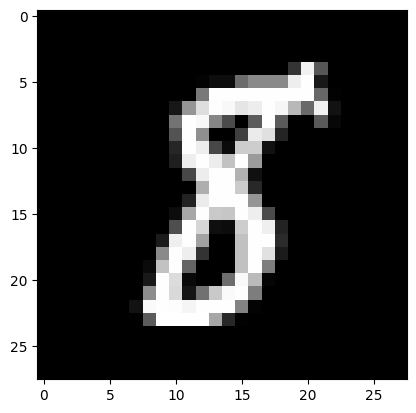

In [57]:
# Visualização das imagens de x
plt.imshow(x_treino[125], cmap='gray')

In [58]:
# Visualização da imagem convertida em números
x_treino[125]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  52, 241,  86,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         13,  13, 108, 137, 137, 137, 238, 254,  24,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 121,
        254, 254, 254, 254, 254, 254, 254, 254, 103,   2,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  23, 149, 222,
        254, 248, 229, 237, 254, 246, 184, 105, 241,  18,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 115, 254, 248,
        134,  75,   0,  91, 254,  91,   0,   0,  90,   7,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  83, 254, 143,
          0,   0,  63, 235, 224,  37,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 254, 238,
         71,  11, 204, 205,  17,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 238, 254,
        237, 194, 254, 155,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  71, 237,
        254, 254, 178,  16,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 174,
        254, 254, 203,  41,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  34, 235,
        254, 254, 254, 149,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  12, 167, 254,
        201, 198, 254, 238,  75,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  78, 254, 214,
         15,  12, 205, 254, 239,  35,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  27, 239, 254, 162,
          0,   0, 193, 254, 254,  43,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 138, 254, 238,  51,
          0,   0, 193, 254, 225,  27,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  10, 194, 254, 101,   0,
          0,   0, 193, 254, 125,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  25, 254, 220,   9,   0,
          0, 109, 249, 186,   5,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 141, 254, 217,  20, 113,
        201, 250, 254, 125,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 250, 254, 253, 245, 254,
        254, 254, 131,   3,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   1,  91, 255, 255, 255, 255,
        166,  39,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [59]:
x_treino[125].max()

np.uint8(255)

In [60]:
# Remodelar os dados para duas dimensões (28 * 28 = 784)
x_treino_remodelado = x_treino.reshape((60000, 784))
x_teste_remodelado = x_teste.reshape((10000, 784))

In [61]:
# Normalização dos dados para uma escala de 0 a 1,
#anteriormente os dados estavam em uma escala de 0 a 255
x_treino_normalizado = x_treino_remodelado.astype('float32') / 255
x_teste_normalizado = x_teste_remodelado.astype('float32') / 255

In [62]:
# Definição do modelo
modelo = Sequential()

# 1ª Camada oculta, neurônios de entrada (784)
modelo.add(Dense(30, input_dim=784, kernel_initializer='normal', activation='relu'))

# 2ª Camada oculta
modelo.add(Dense(30, kernel_initializer='normal', activation='relu'))

# Camada de saída
modelo.add(Dense(10, kernel_initializer='normal', activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
# Otimizador
otimizador = SGD()

In [64]:
# Função de custo 'categorical_crossentropy'; otimização estocástica; métrica de avaliação
modelo.compile(loss='categorical_crossentropy', optimizer=otimizador, metrics=['acc'])

In [65]:
# Treinamento do modelo
historico = modelo.fit(x_treino_normalizado, y_treino_convertido, epochs=40, batch_size=100, validation_data=(x_teste_normalizado, y_teste_convertido))

Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.1474 - loss: 2.2983 - val_acc: 0.3537 - val_loss: 2.2693
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.3481 - loss: 2.2276 - val_acc: 0.3852 - val_loss: 1.9015
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.4952 - loss: 1.6569 - val_acc: 0.7276 - val_loss: 0.9428
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.7541 - loss: 0.8434 - val_acc: 0.8197 - val_loss: 0.6285
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8248 - loss: 0.6075 - val_acc: 0.8533 - val_loss: 0.4999
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8580 - loss: 0.4963 - val_acc: 0.8710 - val_loss: 0.4398
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8728 - loss: 0.4469 - val_acc: 0.8810 - val_loss: 0.4025
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.8810 - loss: 0.4183 - val_acc: 0.8904 - val_loss: 0.3812
Epoch 9/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

In [66]:
# Extração de informações - acurácia dos dados de treino
historico.history['acc']

[0.24228332936763763,
 0.3470333218574524,
 0.5903499722480774,
 0.774733304977417,
 0.8355666399002075,
 0.861133337020874,
 0.8752166628837585,
 0.8845333456993103,
 0.8920666575431824,
 0.8958166837692261,
 0.9001166820526123,
 0.9035833477973938,
 0.9067666530609131,
 0.9097999930381775,
 0.9119833111763,
 0.9146666526794434,
 0.9165833592414856,
 0.9183666706085205,
 0.9203833341598511,
 0.9225333333015442,
 0.92371666431427,
 0.9259999990463257,
 0.9275500178337097,
 0.929183304309845,
 0.9308000206947327,
 0.9318000078201294,
 0.933566689491272,
 0.9350333213806152,
 0.9366999864578247,
 0.9377833604812622,
 0.93913334608078,
 0.9402666687965393,
 0.9413999915122986,
 0.9419666528701782,
 0.9434833526611328,
 0.9448333382606506,
 0.9459499716758728,
 0.9469500184059143,
 0.9475333094596863,
 0.9485333561897278]

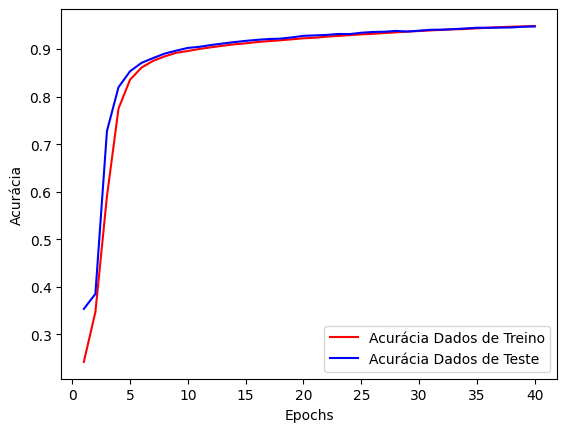

In [67]:
# Gráfico de comparação das acurácias de treino e teste

# Eixo Y
acuracia_treino = historico.history['acc']
acuracia_teste = historico.history['val_acc']

#Eixo X
epochs = range(1, len(acuracia_treino)+1)

plt.plot(epochs, acuracia_treino, '-r', label='Acurácia Dados de Treino')
plt.plot(epochs, acuracia_teste, '-b', label='Acurácia Dados de Teste')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.show()

In [70]:
# Predição
predicoes = modelo.predict(x_teste_normalizado)
print(predicoes[0:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[0.00 0.00 0.00 0.00 0.00 0.00 0.00 1.00 0.00 0.00]
 [0.00 0.00 0.98 0.02 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.98 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.97 0.00 0.00 0.00 0.00 0.02]
 [0.00 0.99 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.95 0.01 0.00 0.00 0.02 0.01]
 [0.00 0.00 0.00 0.01 0.01 0.00 0.00 0.00 0.00 0.97]
 [0.00 0.00 0.00 0.00 0.00 0.00 1.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 0.01 0.00 0.00 0.01 0.00 0.98]]
